# Environment Setup

In [1]:
import os

# Hadoop (must be set BEFORE Spark starts)
os.environ["HADOOP_HOME"] = r"C:\hadoop-3.0.0"
os.environ["hadoop.home.dir"] = r"C:\hadoop-3.0.0"
os.environ["PATH"] = os.environ["HADOOP_HOME"] + r"\bin;" + os.environ["PATH"]

In [2]:
import os

os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-11.0.30.7-hotspot"
os.environ["SPARK_HOME"] = r"C:\Users\HP\Downloads\spark-3.5.8-bin-hadoop3\spark-3.5.8-bin-hadoop3"
os.environ["PATH"] = os.environ["SPARK_HOME"] + r"\bin;" + os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]

In [3]:
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.storagelevel import StorageLevel

from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    VectorAssembler, StandardScaler, StringIndexer
)
from pyspark.ml.classification import (
    LogisticRegression, RandomForestClassifier, GBTClassifier
)
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

import time
import numpy as np

# Initialize Spark Session

In [4]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Reddit_Finance_Distributed_ML_Pipeline") \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.python.worker.reuse", "true") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "false") \
    .getOrCreate()

# PySpark Data Engineering

## Data Ingestion and Storage Design

In [5]:
DATA_PATH = r"E:\Datasets\00_combined.csv"

df_raw = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv(DATA_PATH)

df_raw.printSchema()
df_raw.show(5, truncate=False)

root
 |-- id: string (nullable = true)
 |-- title: string (nullable = true)
 |-- text: string (nullable = true)
 |-- created_utc: integer (nullable = true)
 |-- created_datetime: timestamp (nullable = true)
 |-- score: integer (nullable = true)
 |-- num_comments: integer (nullable = true)
 |-- upvote_ratio: double (nullable = true)
 |-- subreddit: string (nullable = true)
 |-- company: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)

+-------+------------------------------------------------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Data Validation at Ingestion

In [6]:
from pyspark.sql import functions as F

# Mandatory columns check
required_cols = [
    "id", "title", "text", "created_utc", "created_datetime",
    "score", "num_comments", "upvote_ratio",
    "subreddit", "company", "year", "month"
]

missing_cols = set(required_cols) - set(df_raw.columns)
assert len(missing_cols) == 0, f"Missing columns: {missing_cols}"

# Drop invalid rows
df = df_raw.dropna(subset=["id", "company", "created_datetime"])

## Partitioning Strategy (Query-Aligned)

In [7]:
df = df.repartition("company")

# Distributed Data Processing Pipeline

## Basic Cleaning (Spark-native)

In [8]:
df_clean = (
    df
    .withColumn("title", F.lower(F.col("title")))
    .withColumn("text", F.lower(F.col("text")))
    .filter(F.length("title") > 10)
    .filter(F.length("text") > 30)
    .withColumn("score", F.col("score").cast("int"))
    .withColumn("num_comments", F.col("num_comments").cast("int"))
    .withColumn("upvote_ratio", F.col("upvote_ratio").cast("double"))
)

## Memory Management Strategy

In [9]:
df_clean.persist(StorageLevel.MEMORY_AND_DISK)
print("Cached rows:", df_clean.count())

Cached rows: 4906


In [10]:
df_clean.unpersist()

DataFrame[id: string, title: string, text: string, created_utc: int, created_datetime: timestamp, score: int, num_comments: int, upvote_ratio: double, subreddit: string, company: string, year: int, month: int]

## Broadcast Join Example

In [11]:
company_lookup = (
    df_clean.select("company")
    .distinct()
    .withColumn("company_flag", F.lit(1))
)

df_joined = df_clean.join(
    F.broadcast(company_lookup),
    on="company",
    how="left"
)

## Error Handling & Lineage

In [12]:
try:
    df_joined.count()
except Exception as e:
    print("Pipeline failure:", e)

# Performance Optimization

## Shuffle & Partition Tuning

In [13]:
spark.conf.get("spark.sql.shuffle.partitions")

'200'

In [14]:
spark.conf.set("spark.sql.shuffle.partitions", 150)

# Exploratory Data Analysis

In [15]:
import matplotlib.pyplot as plt

## EDA Plot 1: Posts Over Time

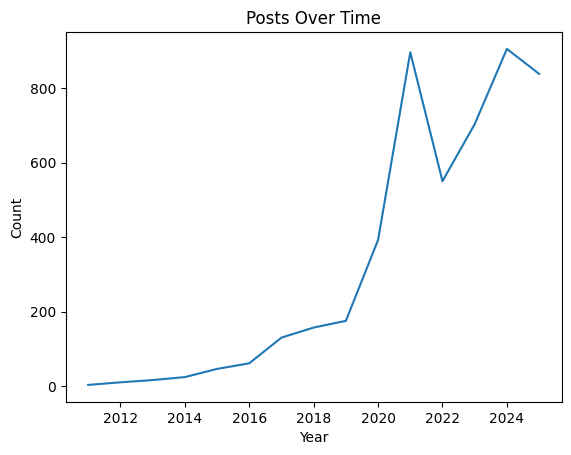

In [16]:
eda_time = df_clean.groupBy("year").count().orderBy("year").toPandas()

plt.figure()
plt.plot(eda_time["year"], eda_time["count"])
plt.title("Posts Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

## EDA Plot 2: Top Companies by Volume

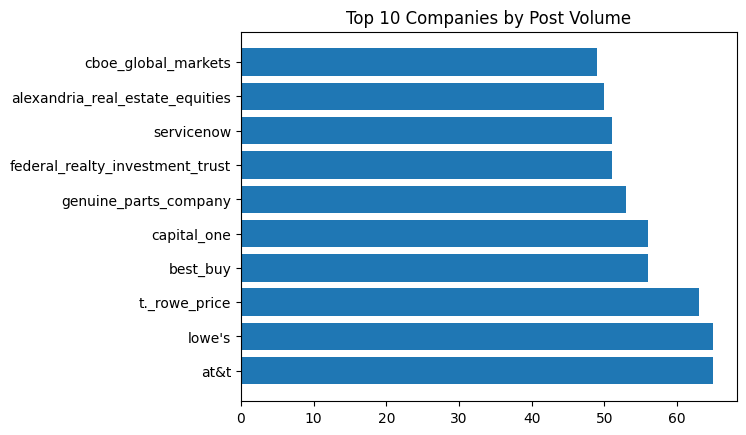

In [17]:
eda_comp = (
    df_clean.groupBy("company")
    .count()
    .orderBy(F.desc("count"))
    .limit(10)
    .toPandas()
)

plt.figure()
plt.barh(eda_comp["company"], eda_comp["count"])
plt.title("Top 10 Companies by Post Volume")
plt.show()

## EDA Plot 3: Score vs Comments

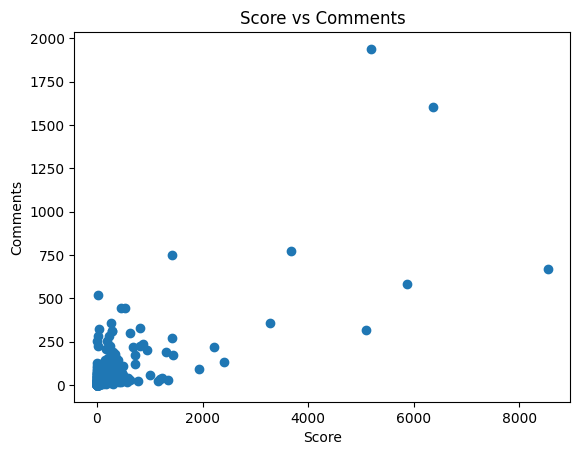

In [18]:
eda_scatter = df_clean.select("score", "num_comments").sample(0.1).toPandas()

plt.figure()
plt.scatter(eda_scatter["score"], eda_scatter["num_comments"])
plt.xlabel("Score")
plt.ylabel("Comments")
plt.title("Score vs Comments")
plt.show()

## EDA Plot 4: Upvote Ratio Distribution

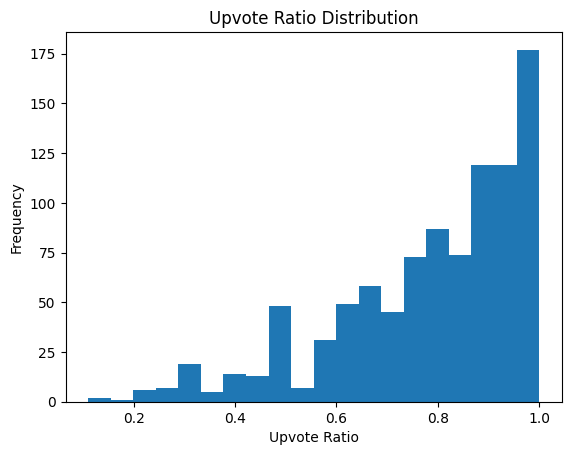

In [19]:
eda_ratio = df_clean.select("upvote_ratio").sample(0.2).toPandas()

plt.figure()
plt.hist(eda_ratio["upvote_ratio"], bins=20)
plt.title("Upvote Ratio Distribution")
plt.xlabel("Upvote Ratio")
plt.ylabel("Frequency")
plt.show()

# Scalability & Distributed ML

## Feature Engineering & Label Definition (Spark)

In [20]:
from pyspark.sql import functions as F

# Simple, explainable label: high vs low engagement
df_ml = df_clean.withColumn(
    "label",
    F.when((F.col("score") > 10) & (F.col("num_comments") > 5), 1).otherwise(0)
)

## Feature Vector Assembly

In [21]:
from pyspark.ml.feature import VectorAssembler

feature_cols = ["score", "num_comments", "upvote_ratio"]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

df_ml = assembler.transform(df_ml).select("features", "label")

## Train / Test Split

In [22]:
train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=42)

## MLlib Algorithms (3 Models)

## Logistic Regression

In [23]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=20
)

## Random Forest Classifier

In [24]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=50,
    maxDepth=8
)

## Gradient Boosted Trees

In [25]:
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(
    featuresCol="features",
    labelCol="label",
    maxIter=20,
    maxDepth=5
)

## Custom Transformer (Domain-Specific)

## Engagement Score Transformer

In [26]:
from pyspark.ml import Transformer
from pyspark.sql.functions import col
from pyspark.ml.util import DefaultParamsReadable, DefaultParamsWritable

class EngagementScoreTransformer(
    Transformer,
    DefaultParamsReadable,
    DefaultParamsWritable
):
    def _transform(self, df):
        return df.withColumn(
            "engagement_score",
            col("score") * col("upvote_ratio") + col("num_comments")
        )

In [27]:
eng_transformer = EngagementScoreTransformer()
df_eng = eng_transformer.transform(df_clean)

## CrossValidator & Hyperparameter Tuning

In [28]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    metricName="areaUnderROC"
)

## Hyperparameter Grid (Computationally Constrained)

In [29]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

lr_param_grid = (
    ParamGridBuilder()
    .addGrid(lr.regParam, [0.01, 0.1])
    .addGrid(lr.elasticNetParam, [0.0, 0.5])
    .build()
)

## Distributed Cross Validation

In [30]:
cv_lr = CrossValidator(
    estimator=lr,
    estimatorParamMaps=lr_param_grid,
    evaluator=evaluator,
    numFolds=3,
    parallelism=4
)